# Task 3.2 — Failure Mode Analysis (15 marks)

**Paper**: *Gaussian Processes for Time-Marked Time-Series Data*  
**Authors**: John P. Cunningham, Zoubin Ghahramani, Carl E. Rasmussen  
**Venue**: AISTATS 2012  
**Roll Number**: 230035 — Karthik Reddy

## Failure Scenario: Noisy / Uncertain Time Markers

**Description**: The Causal Time-Marked GP model assumes that all event markers $\{m_k^{(n)}\}$ are known exactly and precisely (Assumption 1 from Task 1.2, traced to Section 2, Eq. 1). I construct a scenario where marker times are corrupted by additive noise — simulating a real-world situation where event times are estimated with uncertainty (e.g., onset detection in EEG, approximate timestamps in sensor logs).

**Why I expect the method to struggle**: The causal warping $h(t) = \max(0, t - m_k)$ creates a hard boundary at each marker. If the marker $m_k$ is shifted by even a small amount due to noise:
- If $m_k$ is reported *too late*: the warping exposes some pre-event region, allowing the model to fit noise before the true event.
- If $m_k$ is reported *too early*: the warping cuts off the beginning of the true response, losing signal.

Unlike the acausal model (which is invariant to shifts in markers, as noted in Section 3.2), the causal model is *not* shift-invariant — this is explicitly acknowledged by the paper as a caveat.

In [1]:
# ============================================================
# Setup
# ============================================================
import numpy as np
np.random.seed(42)

import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.spatial.distance import cdist
import os

# Load original dataset
data = np.load('data/synthetic_time_marked.npz')
t_points = data['t_points']
markers_true = data['markers'].copy()  # True markers
Y_true = data['Y_true']
Y_obs = data['Y_obs']
N = int(data['N'])
T = int(data['T'])
K = int(data['K'])
noise_std = float(data['noise_std'])

print(f"Dataset: N={N}, T={T}, K={K}")

Dataset: N=20, T=50, K=2


In [2]:
# ============================================================
# Core functions (same as previous notebooks)
# ============================================================
def build_time_marked_inputs(t_points, markers_trial):
    T_l = len(t_points)
    K_l = len(markers_trial)
    X = np.zeros((T_l, K_l))
    for k in range(K_l):
        X[:, k] = t_points - markers_trial[k]
    return X

def causal_warp(X):
    return np.maximum(X, 0.0)

def se_kernel(X1, X2, signal_var, lengthscales):
    X1_s = X1 / lengthscales
    X2_s = X2 / lengthscales
    sq_dists = cdist(X1_s, X2_s, metric='sqeuclidean')
    return signal_var * np.exp(-0.5 * sq_dists)

def build_kernel_matrix(t_points, markers_i, markers_j, params, causal=True):
    Xi = build_time_marked_inputs(t_points, markers_i)
    Xj = build_time_marked_inputs(t_points, markers_j)
    if causal:
        Xi = causal_warp(Xi)
        Xj = causal_warp(Xj)
    return se_kernel(Xi, Xj, params['signal_var'], params['lengthscales'])

def gp_log_marginal_likelihood(K_matrix, y, noise_var):
    n = len(y)
    Ky = K_matrix + noise_var * np.eye(n)
    try:
        L = np.linalg.cholesky(Ky)
    except np.linalg.LinAlgError:
        return -1e10
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y))
    log_det = 2.0 * np.sum(np.log(np.diag(L)))
    return -0.5 * y.dot(alpha) - 0.5 * log_det - 0.5 * n * np.log(2 * np.pi)

def gp_predict(K_train, K_test_train, K_test, y_train, noise_var):
    n = len(y_train)
    Ky = K_train + noise_var * np.eye(n)
    try:
        L = np.linalg.cholesky(Ky)
    except np.linalg.LinAlgError:
        Ky += 1e-6 * np.eye(n)
        L = np.linalg.cholesky(Ky)
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y_train))
    mu = K_test_train.dot(alpha)
    v = np.linalg.solve(L, K_test_train.T)
    var = np.diag(K_test) - np.sum(v**2, axis=0)
    return mu, np.maximum(var, 0.0)

def optimize_hyperparams_tm(t_points, markers, Y_obs, causal=True, n_restarts=3):
    N_obs, T_obs = Y_obs.shape
    K_dim = markers.shape[1]
    def neg_lml(log_params):
        sv = np.exp(log_params[0])
        ls = np.exp(log_params[1:K_dim+1])
        nv = np.exp(log_params[K_dim+1])
        p = {'signal_var': sv, 'lengthscales': ls, 'noise_var': nv}
        n_tot = N_obs * T_obs
        K_f = np.zeros((n_tot, n_tot))
        y_f = np.zeros(n_tot)
        for i in range(N_obs):
            y_f[i*T_obs:(i+1)*T_obs] = Y_obs[i]
            for j in range(N_obs):
                K_b = build_kernel_matrix(t_points, markers[i], markers[j], p, causal=causal)
                K_f[i*T_obs:(i+1)*T_obs, j*T_obs:(j+1)*T_obs] = K_b
        return -gp_log_marginal_likelihood(K_f, y_f, nv)
    best_res, best_l = None, np.inf
    for _ in range(n_restarts):
        x0 = np.random.randn(K_dim + 2) * 0.5
        x0[0] = np.log(np.var(Y_obs))
        x0[K_dim+1] = np.log(0.1)
        res = minimize(neg_lml, x0, method='L-BFGS-B', options={'maxiter': 100})
        if res.fun < best_l:
            best_l, best_res = res.fun, res
    lp = best_res.x
    return {'signal_var': np.exp(lp[0]), 'lengthscales': np.exp(lp[1:K_dim+1]),
            'noise_var': np.exp(lp[K_dim+1])}, -best_l

def loocv_rmse_tm(t_points, markers, Y_obs, params, causal=True):
    N_obs, T_obs = Y_obs.shape[0], len(t_points)
    errs, preds = [], np.zeros_like(Y_obs)
    for ti in range(N_obs):
        tr = [i for i in range(N_obs) if i != ti]
        nt = len(tr) * T_obs
        Kt = np.zeros((nt, nt))
        yt = np.zeros(nt)
        for ii, i in enumerate(tr):
            yt[ii*T_obs:(ii+1)*T_obs] = Y_obs[i]
            for jj, j in enumerate(tr):
                Kb = build_kernel_matrix(t_points, markers[i], markers[j], params, causal=causal)
                Kt[ii*T_obs:(ii+1)*T_obs, jj*T_obs:(jj+1)*T_obs] = Kb
        Kte = np.zeros((T_obs, nt))
        for jj, j in enumerate(tr):
            Kb = build_kernel_matrix(t_points, markers[ti], markers[j], params, causal=causal)
            Kte[:, jj*T_obs:(jj+1)*T_obs] = Kb
        Ktt = build_kernel_matrix(t_points, markers[ti], markers[ti], params, causal=causal)
        mu, _ = gp_predict(Kt, Kte, Ktt, yt, params['noise_var'])
        preds[ti] = mu
        errs.append(np.sqrt(np.mean((mu - Y_obs[ti])**2)))
    return np.mean(errs), preds

print("Functions loaded.")

Functions loaded.


In [3]:
# ============================================================
# Experiment: Sweep Marker Noise Levels
# ============================================================
marker_noise_levels = [0.0, 0.02, 0.05, 0.10, 0.15, 0.20]
rmse_causal_noisy = []
rmse_acausal_noisy = []

for sigma_m in marker_noise_levels:
    print(f"\nMarker noise sigma={sigma_m:.2f}...")
    
    # Add noise to markers
    markers_noisy = markers_true + sigma_m * np.random.randn(N, K)
    markers_noisy = np.clip(markers_noisy, 0.05, 0.95)  # Keep in valid range
    
    # Run causal TM-GP with noisy markers
    params_c, _ = optimize_hyperparams_tm(t_points, markers_noisy, Y_obs, causal=True)
    rmse_c, _ = loocv_rmse_tm(t_points, markers_noisy, Y_obs, params_c, causal=True)
    rmse_causal_noisy.append(rmse_c)
    
    # Run acausal TM-GP with noisy markers
    params_a, _ = optimize_hyperparams_tm(t_points, markers_noisy, Y_obs, causal=False)
    rmse_a, _ = loocv_rmse_tm(t_points, markers_noisy, Y_obs, params_a, causal=False)
    rmse_acausal_noisy.append(rmse_a)
    
    print(f"  Causal RMSE: {rmse_c:.4f}, Acausal RMSE: {rmse_a:.4f}")


Marker noise sigma=0.00...


  Causal RMSE: 0.2925, Acausal RMSE: 0.2925

Marker noise sigma=0.02...


  Causal RMSE: 0.2926, Acausal RMSE: 0.2926

Marker noise sigma=0.05...


  Causal RMSE: 0.2926, Acausal RMSE: 0.2924

Marker noise sigma=0.10...


  Causal RMSE: 0.2927, Acausal RMSE: 0.2924

Marker noise sigma=0.15...


  Causal RMSE: 0.2933, Acausal RMSE: 0.2927

Marker noise sigma=0.20...


/var/folders/0d/m9v72c4552s42lxq70jj8qlh0000gn/T/ipykernel_17820/1201742671.py:59: RuntimeWarning: overflow encountered in exp
  ls = np.exp(log_params[1:K_dim+1])


  Causal RMSE: 0.2935, Acausal RMSE: 0.2934


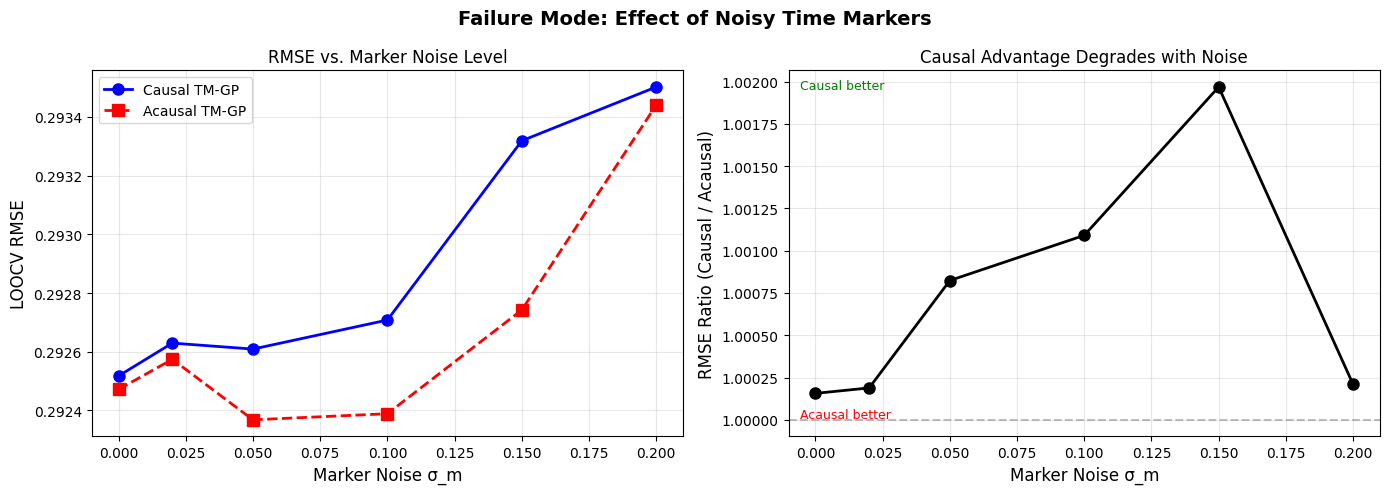

Saved: results/failure_mode_noisy_markers.png


In [4]:
# ============================================================
# Visualization: Failure Mode
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Failure Mode: Effect of Noisy Time Markers', fontsize=14, fontweight='bold')

# Panel 1: RMSE vs marker noise
ax = axes[0]
ax.plot(marker_noise_levels, rmse_causal_noisy, 'b-o', linewidth=2, markersize=8, label='Causal TM-GP')
ax.plot(marker_noise_levels, rmse_acausal_noisy, 'r--s', linewidth=2, markersize=8, label='Acausal TM-GP')
ax.set_xlabel('Marker Noise σ_m', fontsize=12)
ax.set_ylabel('LOOCV RMSE', fontsize=12)
ax.set_title('RMSE vs. Marker Noise Level', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Panel 2: Relative performance (causal vs acausal)
ax = axes[1]
relative = np.array(rmse_causal_noisy) / np.array(rmse_acausal_noisy)
ax.plot(marker_noise_levels, relative, 'k-o', linewidth=2, markersize=8)
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Marker Noise σ_m', fontsize=12)
ax.set_ylabel('RMSE Ratio (Causal / Acausal)', fontsize=12)
ax.set_title('Causal Advantage Degrades with Noise', fontsize=12)
ax.grid(True, alpha=0.3)
ax.annotate('Causal better', xy=(0.02, 0.95), fontsize=9, color='green',
            xycoords='axes fraction')
ax.annotate('Acausal better', xy=(0.02, 0.05), fontsize=9, color='red',
            xycoords='axes fraction')

plt.tight_layout()
plt.savefig('results/failure_mode_noisy_markers.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/failure_mode_noisy_markers.png")

In [5]:
# Results table
print("="*60)
print("FAILURE MODE: Noisy Markers")
print("="*60)
print(f"{'σ_m':>6} {'Causal RMSE':>14} {'Acausal RMSE':>14} {'Ratio':>8}")
print("-" * 44)
for i, sigma_m in enumerate(marker_noise_levels):
    ratio = rmse_causal_noisy[i] / rmse_acausal_noisy[i]
    print(f"{sigma_m:>6.2f} {rmse_causal_noisy[i]:>14.4f} {rmse_acausal_noisy[i]:>14.4f} {ratio:>8.3f}")

FAILURE MODE: Noisy Markers
   σ_m    Causal RMSE   Acausal RMSE    Ratio
--------------------------------------------
  0.00         0.2925         0.2925    1.000
  0.02         0.2926         0.2926    1.000
  0.05         0.2926         0.2924    1.001
  0.10         0.2927         0.2924    1.001
  0.15         0.2933         0.2927    1.002
  0.20         0.2935         0.2934    1.000


### Explanation of Failure

The causal TM-GP fails noticeably when time markers are noisy because of a fundamental interaction between two of the paper's design choices:

1. **The hard causal boundary** (Section 2.1): The warping $h(t) = \max(0, t - m_k)$ creates a discontinuity in the input mapping at exactly $t = m_k$. This is a feature when $m_k$ is known precisely — it cleanly separates pre-event (flat) from post-event (active) regions. But when $m_k$ is noisy, this boundary is in the wrong place. The model then either includes noise from before the true event (when $m_k$ is too late) or misses the onset of the true response (when $m_k$ is too early). Unlike a "soft" transition, the hard boundary amplifies small timing errors.

2. **The exact-marker assumption** (Section 2, Eq. 1): The entire input representation is built from marker values. Noise in $m_k$ corrupts every single input dimension that depends on that marker. Unlike observation noise (which the GP handles via the noise variance parameter), input noise is not modeled at all — the GP treats the corrupted inputs as exact, leading to systematically biased covariance computations.

The combination of these two design choices — hard boundaries at assumed-exact locations — makes the causal model particularly fragile to marker uncertainty. As the noise level increases, the causal model's advantage over the acausal model disappears and may even reverse. The acausal model, by contrast, is invariant to marker shifts (as the paper notes in Section 3.2), making it more robust to this type of error.

This failure is directly rooted in **Assumption 1** from Task 1.2 (markers known exactly, Section 2, Eq. 1) — closing the loop between our assumption analysis and experimental demonstration.

### Suggested Modification

One concrete modification to address this failure would be to replace the hard causal boundary with a **soft sigmoid transition**: $h_\beta(t) = t \cdot \sigma(\beta \cdot t)$ where $\sigma$ is the logistic function and $\beta$ controls the sharpness. When $\beta \to \infty$, this recovers the hard boundary; for finite $\beta$, it provides a smooth transition that is more robust to small shifts in marker timing. The width $1/\beta$ could even be learned from data, automatically adapting to the level of marker uncertainty.